<a href="https://colab.research.google.com/github/nomanabdullah04/DeepLearning/blob/main/Dropout_layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 48. Dropout Layer: Theory, Diagram, Mathematical Intuition, and Trade-offs

### **1. What is a Dropout Layer?**
**Dropout** is a powerful regularization technique used in neural networks to prevent **overfitting**. During training, it randomly "drops out" (i.e., temporarily sets to zero) a fraction of neurons in a given layer at each iteration, forcing the network to learn redundant and robust features.

---

### **2. Conceptual Diagram**

$$\text{Standard Layer (Fully Connected)} \quad \longrightarrow \quad \text{Dropout Layer (with } p = 0.5 \text{)}$$

```text
[Input]        [Hidden Layer]             [Input]        [Dropout Applied]
  (o) ------------> (o)                                    (o) ------------> (o)
                    │                                                        │
  (o) ------------> (o)                    -->             (o) ------------> [X]  (Dropped)
                    │                                                        │
  (o) ------------> (o)                                    [X] (Dropped) --> (o)

## 49. Dropout Layer: Detailed Analysis & Mathematical Intuition

### **3. How It Works & Mathematical Intuition**

#### **During Training:**
* **Probability of Dropping:** A dropout probability $p$ (e.g., $p = 0.5$) specifies the probability that a neuron is silenced.
* **Binary Mask Vector:** A binary mask vector $r^{(l)}$ is sampled from a Bernoulli distribution for layer $l$:
  $$r^{(l)} \sim \text{Bernoulli}(1 - p)$$
* **Element-wise Masking:** The output activations are scaled or masked element-wise:
  $$\tilde{y}^{(l)} = r^{(l)} \odot y^{(l)}$$
* **Inverted Dropout:** To avoid scaling outputs at test time, modern frameworks scale the surviving activations during training by dividing by $(1 - p)$:
  $$\tilde{y}^{(l)} = \frac{r^{(l)} \odot y^{(l)}}{1 - p}$$

#### **During Testing / Inference:**
* No dropout is applied. All neurons are active, and the network uses its full capacity because the weights were already scaled appropriately during training.

### **4. Advantages of Dropout**
* **Prevents Overfitting:** Stops neurons from co-adapting too strongly to specific training patterns, forcing them to learn independent, useful features.
* **Implicit Model Ensembling:** Each training step drops a different set of neurons, effectively training an exponential number of unique sub-networks ($2^N$ architectures) that average their predictions at test time.


### **5. Disadvantages of Dropout**
* **Increased Training Time:** Because parts of the network are randomly disabled at each step, convergence can take more epochs.
* **Loss of Information:** If the dropout rate $p$ is set too high (e.g., $> 0.5$), the network may discard critical patterns and underfit the training data.

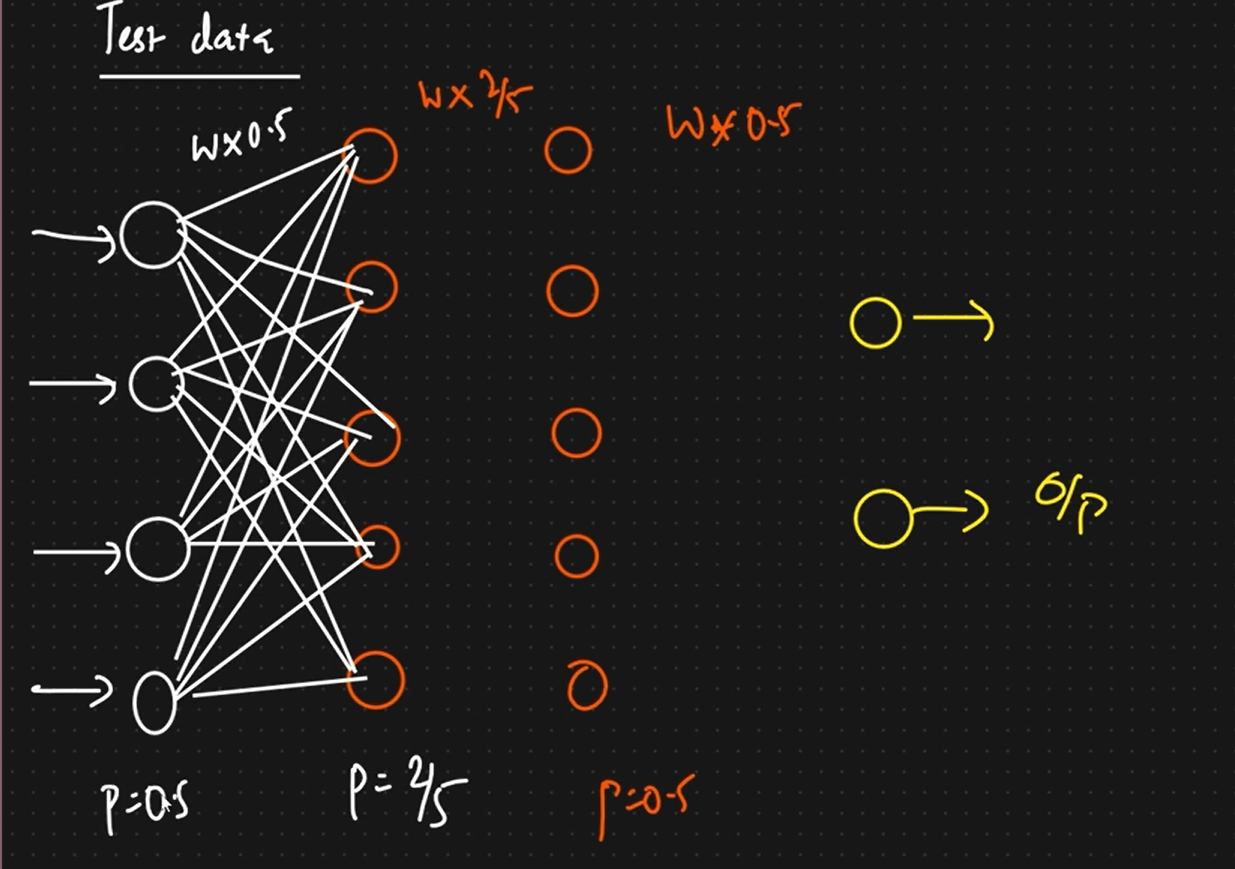